# Experimento 1 — Otimizadores
## Comparação de SGD, SGD+momentum e Adam

## 1. Setup

In [1]:
import os
import json
import time
import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds()
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Path("checkpoints").mkdir(exist_ok=True)
Path("figs").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

Device: cuda
GPU: NVIDIA RTX A6000


In [2]:
from src.gtsrb import (
    get_dataloaders,
    save_predictions,
    NUM_CLASSES,
    GTSRB_CLASSES,
)

print(f"NUM_CLASSES = {NUM_CLASSES}")

NUM_CLASSES = 43


## 2. Hiperparâmetros e carregamento dos dados

In [ ]:
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 20
NUM_WORKERS = 0  
train_loader, val_loader, test_loader = get_dataloaders(
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

print(f"Treino:    {len(train_loader.dataset):>6d} amostras  ({len(train_loader)} batches)")
print(f"Validação: {len(val_loader.dataset):>6d} amostras  ({len(val_loader)} batches)")
print(f"Teste:     {len(test_loader.dataset):>6d} amostras  ({len(test_loader)} batches)")

Treino:     21312 amostras  (167 batches)
Validação:   5328 amostras  (42 batches)
Teste:      12630 amostras  (99 batches)


## 3. Arquitetura (idêntica ao baseline)

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        spatial = img_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * spatial * spatial, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def build_model():
    set_all_seeds(SEED)
    return BaselineCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)

m1 = build_model()
m2 = build_model()
same = all(torch.equal(p1, p2) for p1, p2 in zip(m1.parameters(), m2.parameters()))
print(f"Pesos iniciais reprodutíveis: {same}")
del m1, m2

Pesos iniciais reprodutíveis: True


## 4. Funções de treino e avaliação

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    ys, ps = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        preds = model(images).argmax(1).cpu().numpy()
        ps.append(preds)
        ys.append(labels.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def per_class_accuracy(y_true, y_pred, num_classes):
    accs = np.zeros(num_classes)
    counts = np.zeros(num_classes, dtype=int)
    for c in range(num_classes):
        mask = y_true == c
        counts[c] = mask.sum()
        accs[c] = (y_pred[mask] == c).mean() if counts[c] > 0 else 0.0
    return accs, counts

## 5. Função de treino completa por experimento

In [6]:
def run_experiment(name, optimizer_factory, num_epochs=NUM_EPOCHS):
    """
    optimizer_factory: callable(params) -> torch.optim.Optimizer
    Retorna: dict com history, best_val_acc, tempo, checkpoint_path
    """
    print(f"\n{'=' * 70}")
    print(f"  Treinando: {name}")
    print(f"{'=' * 70}")

    model = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_factory(model.parameters())
    print(f"  Optimizer: {optimizer.__class__.__name__}")
    for g in optimizer.param_groups:
        print(f"  Hyperparams: lr={g.get('lr')}, "
              f"momentum={g.get('momentum', '-')}, "
              f"betas={g.get('betas', '-')}")

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_epoch = 0.0, 0
    ckpt_path = f"checkpoints/exp1_{name}_best.pt"

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        flag = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), ckpt_path)
            flag = "  <-- melhor val_acc"

        print(f"  Epoch {epoch:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f}{flag}")
    elapsed = time.time() - t0

    print(f"\n  Tempo: {elapsed:.1f}s | Melhor val_acc: {best_val_acc:.4f} (epoch {best_epoch})")

    return {
        "name": name,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "elapsed_sec": elapsed,
        "ckpt_path": ckpt_path,
    }

## 6. Rodada 1 — SGD (sem momentum)

In [7]:
res_sgd = run_experiment(
    name="sgd",
    optimizer_factory=lambda p: optim.SGD(p, lr=0.01),
)


  Treinando: sgd
  Optimizer: SGD
  Hyperparams: lr=0.01, momentum=0, betas=-
  Epoch 01/20 | train_loss=3.5230 acc=0.0777 | val_loss=3.3794 acc=0.1096  <-- melhor val_acc
  Epoch 02/20 | train_loss=3.2816 acc=0.1369 | val_loss=3.1813 acc=0.1695  <-- melhor val_acc
  Epoch 03/20 | train_loss=2.9848 acc=0.2430 | val_loss=2.7962 acc=0.2898  <-- melhor val_acc
  Epoch 04/20 | train_loss=2.4662 acc=0.3445 | val_loss=2.3363 acc=0.3144  <-- melhor val_acc
  Epoch 05/20 | train_loss=1.9321 acc=0.4563 | val_loss=1.7965 acc=0.4574  <-- melhor val_acc
  Epoch 06/20 | train_loss=1.5344 acc=0.5570 | val_loss=1.6317 acc=0.5006  <-- melhor val_acc
  Epoch 07/20 | train_loss=1.2247 acc=0.6442 | val_loss=1.6288 acc=0.5263  <-- melhor val_acc
  Epoch 08/20 | train_loss=1.0018 acc=0.7088 | val_loss=1.2503 acc=0.6952  <-- melhor val_acc
  Epoch 09/20 | train_loss=0.8434 acc=0.7533 | val_loss=0.8393 acc=0.7425  <-- melhor val_acc
  Epoch 10/20 | train_loss=0.7126 acc=0.7912 | val_loss=0.6339 acc=0.8054  

## 7. Rodada 2 — SGD + momentum

In [8]:
res_sgd_mom = run_experiment(
    name="sgd_momentum",
    optimizer_factory=lambda p: optim.SGD(p, lr=0.01, momentum=0.9),
)


  Treinando: sgd_momentum
  Optimizer: SGD
  Hyperparams: lr=0.01, momentum=0.9, betas=-
  Epoch 01/20 | train_loss=2.7761 acc=0.2486 | val_loss=1.5663 acc=0.5099  <-- melhor val_acc
  Epoch 02/20 | train_loss=0.8461 acc=0.7363 | val_loss=0.4456 acc=0.8589  <-- melhor val_acc
  Epoch 03/20 | train_loss=0.2941 acc=0.9130 | val_loss=0.2028 acc=0.9444  <-- melhor val_acc
  Epoch 04/20 | train_loss=0.1538 acc=0.9577 | val_loss=0.1948 acc=0.9366
  Epoch 05/20 | train_loss=0.1040 acc=0.9706 | val_loss=0.0947 acc=0.9782  <-- melhor val_acc
  Epoch 06/20 | train_loss=0.0659 acc=0.9829 | val_loss=0.0717 acc=0.9827  <-- melhor val_acc
  Epoch 07/20 | train_loss=0.0455 acc=0.9883 | val_loss=0.0704 acc=0.9827
  Epoch 08/20 | train_loss=0.0304 acc=0.9935 | val_loss=0.0670 acc=0.9814
  Epoch 09/20 | train_loss=0.0243 acc=0.9945 | val_loss=0.0540 acc=0.9869  <-- melhor val_acc
  Epoch 10/20 | train_loss=0.0160 acc=0.9965 | val_loss=0.0522 acc=0.9889  <-- melhor val_acc
  Epoch 11/20 | train_loss=0.0

## 8. Rodada 3 — Adam

In [9]:
res_adam = run_experiment(
    name="adam",
    optimizer_factory=lambda p: optim.Adam(p, lr=1e-3),
)


  Treinando: adam
  Optimizer: Adam
  Hyperparams: lr=0.001, momentum=-, betas=(0.9, 0.999)
  Epoch 01/20 | train_loss=1.4563 acc=0.5957 | val_loss=0.4394 acc=0.8628  <-- melhor val_acc
  Epoch 02/20 | train_loss=0.2400 acc=0.9347 | val_loss=0.1520 acc=0.9600  <-- melhor val_acc
  Epoch 03/20 | train_loss=0.1152 acc=0.9703 | val_loss=0.0980 acc=0.9743  <-- melhor val_acc
  Epoch 04/20 | train_loss=0.0696 acc=0.9834 | val_loss=0.0613 acc=0.9848  <-- melhor val_acc
  Epoch 05/20 | train_loss=0.0389 acc=0.9909 | val_loss=0.0470 acc=0.9882  <-- melhor val_acc
  Epoch 06/20 | train_loss=0.0328 acc=0.9920 | val_loss=0.0501 acc=0.9872
  Epoch 07/20 | train_loss=0.0157 acc=0.9965 | val_loss=0.0604 acc=0.9822
  Epoch 08/20 | train_loss=0.0242 acc=0.9937 | val_loss=0.0441 acc=0.9887  <-- melhor val_acc
  Epoch 09/20 | train_loss=0.0093 acc=0.9980 | val_loss=0.0418 acc=0.9891  <-- melhor val_acc
  Epoch 10/20 | train_loss=0.0078 acc=0.9985 | val_loss=0.0399 acc=0.9904  <-- melhor val_acc
  Epoch

In [ ]:
all_results = {"sgd": res_sgd, "sgd_momentum": res_sgd_mom, "adam": res_adam}

to_save = {
    name: {k: v for k, v in r.items() if k != "ckpt_path"}
    for name, r in all_results.items()
}
with open("checkpoints/exp1_summary.json", "w") as f:
    json.dump(to_save, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp1_summary.json")

Resumo salvo em checkpoints/exp1_summary.json


## 9. Comparação de curvas de treino

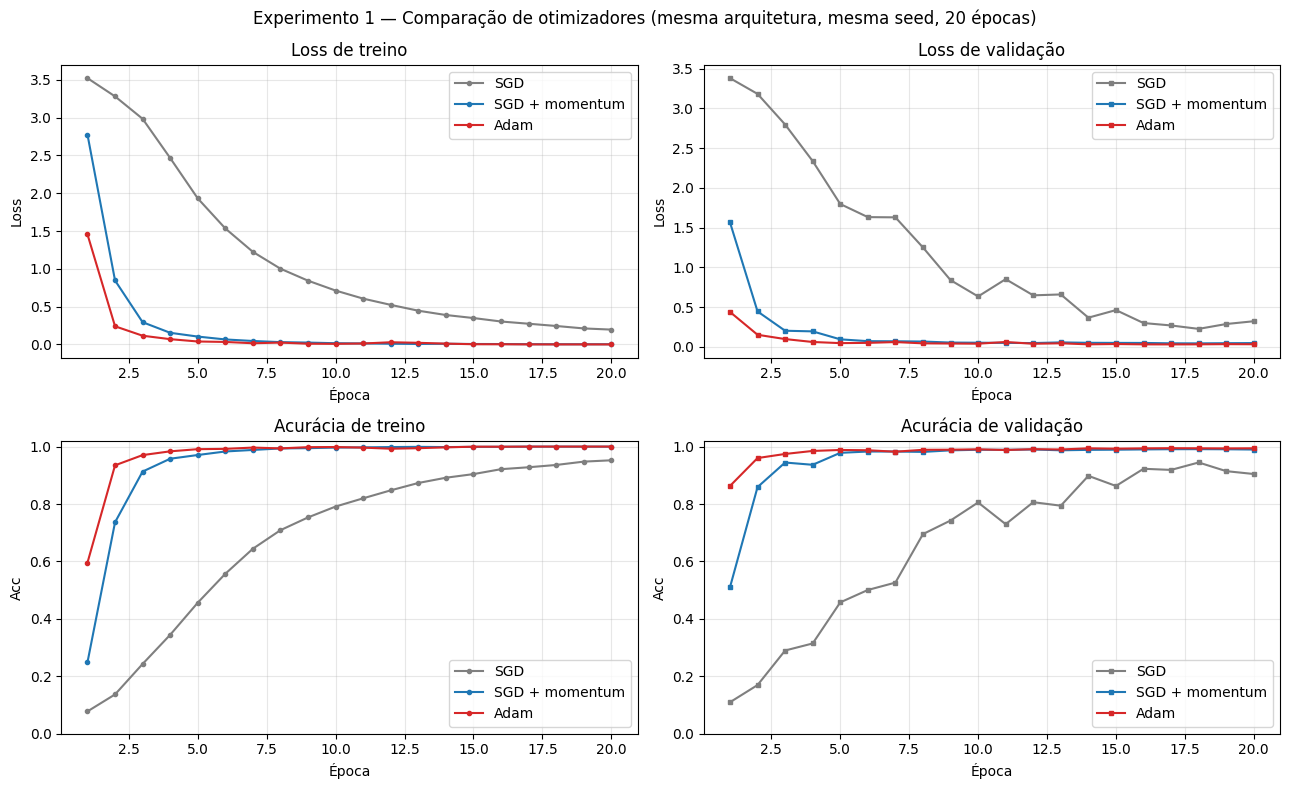

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)
colors = {"sgd": "tab:gray", "sgd_momentum": "tab:blue", "adam": "tab:red"}
labels = {"sgd": "SGD", "sgd_momentum": "SGD + momentum", "adam": "Adam"}

for name, r in all_results.items():
    axes[0, 0].plot(epochs, r["history"]["train_loss"], "o-", color=colors[name], label=labels[name], markersize=3)
axes[0, 0].set_title("Loss de treino"); axes[0, 0].set_xlabel("Época"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

for name, r in all_results.items():
    axes[0, 1].plot(epochs, r["history"]["val_loss"], "s-", color=colors[name], label=labels[name], markersize=3)
axes[0, 1].set_title("Loss de validação"); axes[0, 1].set_xlabel("Época"); axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

for name, r in all_results.items():
    axes[1, 0].plot(epochs, r["history"]["train_acc"], "o-", color=colors[name], label=labels[name], markersize=3)
axes[1, 0].set_title("Acurácia de treino"); axes[1, 0].set_xlabel("Época"); axes[1, 0].set_ylabel("Acc")
axes[1, 0].legend(loc="lower right"); axes[1, 0].grid(alpha=0.3); axes[1, 0].set_ylim(0, 1.02)

for name, r in all_results.items():
    axes[1, 1].plot(epochs, r["history"]["val_acc"], "s-", color=colors[name], label=labels[name], markersize=3)
axes[1, 1].set_title("Acurácia de validação"); axes[1, 1].set_xlabel("Época"); axes[1, 1].set_ylabel("Acc")
axes[1, 1].legend(loc="lower right"); axes[1, 1].grid(alpha=0.3); axes[1, 1].set_ylim(0, 1.02)

plt.suptitle("Experimento 1 — Comparação de otimizadores (mesma arquitetura, mesma seed, 20 épocas)")
plt.tight_layout()
plt.savefig("figs/exp1_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.1 Velocidade de convergência (épocas pra atingir X%)

In [12]:
THRESHOLDS = [0.50, 0.80, 0.90, 0.95]

def first_epoch_to_reach(acc_list, threshold):
    for i, a in enumerate(acc_list, start=1):
        if a >= threshold:
            return i
    return None

print(f"  {'Otimizador':<20s} | " + " | ".join(f"  ≥{int(t*100)}%" for t in THRESHOLDS))
print("-" * 70)
for name, r in all_results.items():
    eps = [first_epoch_to_reach(r["history"]["val_acc"], t) for t in THRESHOLDS]
    cells_str = " | ".join(f"{('--' if e is None else f'ep {e:>2d}'):>6s}" for e in eps)
    print(f"  {labels[name]:<20s} | {cells_str}")

  Otimizador           |   ≥50% |   ≥80% |   ≥90% |   ≥95%
----------------------------------------------------------------------
  SGD                  |  ep  6 |  ep 10 |  ep 16 |     --
  SGD + momentum       |  ep  1 |  ep  2 |  ep  3 |  ep  5
  Adam                 |  ep  1 |  ep  1 |  ep  2 |  ep  2


### 9.2 Estabilidade do treino

In [13]:
print(f"  {'Otimizador':<20s} | {'val_acc final':>14s} | {'std últimas 5 ep':>17s} | {'max - min últimas 5':>20s}")
print("-" * 80)
for name, r in all_results.items():
    last5 = r["history"]["val_acc"][-5:]
    std5 = float(np.std(last5))
    spread = float(max(last5) - min(last5))
    print(f"  {labels[name]:<20s} | {last5[-1]:>14.4f} | {std5:>17.4f} | {spread:>20.4f}")

  Otimizador           |  val_acc final |  std últimas 5 ep |  max - min últimas 5
--------------------------------------------------------------------------------
  SGD                  |         0.9045 |            0.0133 |               0.0402
  SGD + momentum       |         0.9897 |            0.0005 |               0.0013
  Adam                 |         0.9940 |            0.0002 |               0.0008


### 9.3 Indícios de overfitting

In [14]:
print(f"  {'Otimizador':<20s} | {'train_acc final':>16s} | {'val_acc final':>14s} | {'gap (train-val)':>17s}")
print("-" * 80)
for name, r in all_results.items():
    t_final = r["history"]["train_acc"][-1]
    v_final = r["history"]["val_acc"][-1]
    print(f"  {labels[name]:<20s} | {t_final:>16.4f} | {v_final:>14.4f} | {t_final - v_final:>+17.4f}")

  Otimizador           |  train_acc final |  val_acc final |   gap (train-val)
--------------------------------------------------------------------------------
  SGD                  |           0.9522 |         0.9045 |           +0.0478
  SGD + momentum       |           0.9998 |         0.9897 |           +0.0101
  Adam                 |           1.0000 |         0.9940 |           +0.0060


## 10. Avaliação no conjunto de teste

In [15]:
test_results = {}

for name, r in all_results.items():
    model = BaselineCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
    model.load_state_dict(torch.load(r["ckpt_path"], map_location=DEVICE))
    y_true, y_pred = predict_all(model, test_loader, DEVICE)
    assert y_pred.shape == (12630,)

    per_class_acc, _ = per_class_accuracy(y_true, y_pred, NUM_CLASSES)
    global_acc = float((y_pred == y_true).mean())
    macro_acc = float(per_class_acc.mean())

    test_results[name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }

    print(f"  {labels[name]:<20s} | global_acc={global_acc:.4f} | macro_acc={macro_acc:.4f}")

  SGD                  | global_acc=0.7690 | macro_acc=0.6961
  SGD + momentum       | global_acc=0.8765 | macro_acc=0.8390
  Adam                 | global_acc=0.9134 | macro_acc=0.8768


### 10.1 Resumo comparativo

In [16]:
print(f"  {'Otimizador':<20s} | {'val_acc (best)':>14s} | {'test global':>11s} | {'test macro':>10s} | {'pior cls':>8s} | {'tempo (s)':>10s}")
print("-" * 100)
for name, r in all_results.items():
    tr = test_results[name]
    worst = int(np.argmin(tr["per_class_acc"]))
    worst_acc = float(tr["per_class_acc"].min())
    print(f"  {labels[name]:<20s} | {r['best_val_acc']:>14.4f} | "
          f"{tr['global_acc']:>11.4f} | {tr['macro_acc']:>10.4f} | "
          f"{worst:>2d}={worst_acc:.2f} | {r['elapsed_sec']:>10.1f}")

  Otimizador           | val_acc (best) | test global | test macro | pior cls |  tempo (s)
----------------------------------------------------------------------------------------------------
  SGD                  |         0.9446 |      0.7690 |     0.6961 |  0=0.15 |      502.4
  SGD + momentum       |         0.9910 |      0.8765 |     0.8390 | 30=0.38 |      312.1
  Adam                 |         0.9944 |      0.9134 |     0.8768 |  0=0.43 |      313.9


## 11. Comparação por classe

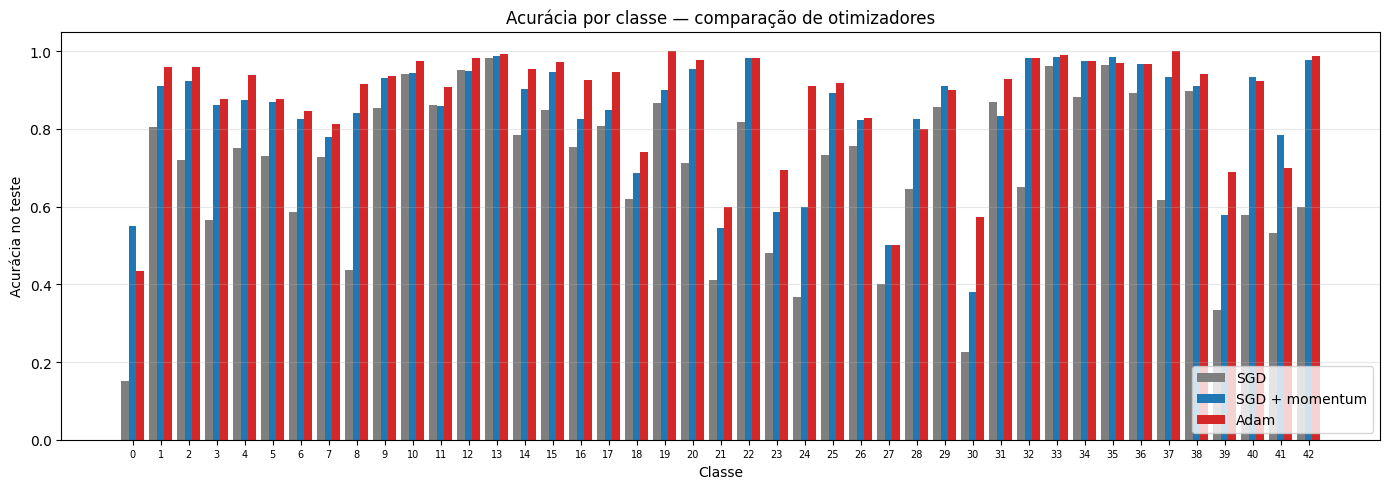

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(NUM_CLASSES)
width = 0.27
for i, (name, tr) in enumerate(test_results.items()):
    ax.bar(x + (i - 1) * width, tr["per_class_acc"], width, label=labels[name], color=colors[name])
ax.set_xlabel("Classe"); ax.set_ylabel("Acurácia no teste")
ax.set_title("Acurácia por classe — comparação de otimizadores")
ax.set_xticks(x); ax.set_xticklabels(x, fontsize=7)
ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figs/exp1_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

### 11.1 Foco nas 5 classes mais difíceis do baseline

In [18]:
HARD_CLASSES = [0, 30, 27, 24, 21]

print(f"  {'Classe':<8s} | " + " | ".join(f"{labels[n]:>16s}" for n in all_results))
print("-" * 80)
for c in HARD_CLASSES:
    row = f"  cls {c:>2d}  | "
    row += " | ".join(f"{test_results[n]['per_class_acc'][c]:>16.4f}" for n in all_results)
    row += f"  ({GTSRB_CLASSES[c]})"
    print(row)

print()
print("  Média sobre as 5 classes difíceis:")
for name in all_results:
    mean_hard = float(np.mean([test_results[name]["per_class_acc"][c] for c in HARD_CLASSES]))
    print(f"    {labels[name]:<20s} = {mean_hard:.4f}")

  Classe   |              SGD |   SGD + momentum |             Adam
--------------------------------------------------------------------------------
  cls  0  |           0.1500 |           0.5500 |           0.4333  (Speed limit (20km/h))
  cls 30  |           0.2267 |           0.3800 |           0.5733  (Beware of ice/snow)
  cls 27  |           0.4000 |           0.5000 |           0.5000  (Pedestrians)
  cls 24  |           0.3667 |           0.6000 |           0.9111  (Road narrows right)
  cls 21  |           0.4111 |           0.5444 |           0.6000  (Double curve)

  Média sobre as 5 classes difíceis:
    SGD                  = 0.3109
    SGD + momentum       = 0.5149
    Adam                 = 0.6036


### 11.2 Quais classes cada otimizador "ganha"?

In [19]:
stacked = np.stack([test_results[n]["per_class_acc"] for n in all_results])
names_list = list(all_results.keys())
winners = stacked.argmax(axis=0)
counts = np.bincount(winners, minlength=3)
print("Em quantas classes cada otimizador foi o melhor (43 no total):")
for i, n in enumerate(names_list):
    print(f"  {labels[n]:<20s} : {counts[i]:>2d} classes")

Em quantas classes cada otimizador foi o melhor (43 no total):
  SGD                  :  0 classes
  SGD + momentum       : 11 classes
  Adam                 : 32 classes


## 12. Salvar predições

In [20]:
for name, tr in test_results.items():
    out_path = f"results/predicoes_exp1_{name}.csv"
    save_predictions(
        tr["y_pred"],
        out_path,
        experiment_name=f"Exp1 {labels[name]} | img=32 | 20 epochs",
    )
    print(f"  {out_path}  ({len(tr['y_pred'])} predições)")

  results/predicoes_exp1_sgd.csv  (12630 predições)
  results/predicoes_exp1_sgd_momentum.csv  (12630 predições)
  results/predicoes_exp1_adam.csv  (12630 predições)
